In [36]:
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

base_path = "/Users/olaoluwatunmise/Germany-Energy-Price-Forecast/PowerCast-Datasets"



# Use recursive search inside all subdirectories and  **/ for a recursive search:
csv_file = glob.glob(os.path.join(base_path, "**/*data.csv"), recursive=True)

print(csv_file)

for i in csv_file:
    print(i)

['/Users/olaoluwatunmise/Germany-Energy-Price-Forecast/PowerCast-Datasets/Merged-Data/price_data.csv', '/Users/olaoluwatunmise/Germany-Energy-Price-Forecast/PowerCast-Datasets/Merged-Data/features_data.csv']
/Users/olaoluwatunmise/Germany-Energy-Price-Forecast/PowerCast-Datasets/Merged-Data/price_data.csv
/Users/olaoluwatunmise/Germany-Energy-Price-Forecast/PowerCast-Datasets/Merged-Data/features_data.csv


In [37]:
# Select the 3 specific files
selected_files = [
    "price_data.csv",
    "features_data.csv",
    ]

# Filter the files to get full paths
selected_paths = [f for f in csv_file if any(name in f for name in selected_files)]


# Read and merge the files
df_list = [pd.read_csv(file, parse_dates=["timestamp"], low_memory=False) for file in selected_paths]

# Merge DataFrames on 'timestamp
merged_df = pd.merge(df_list[0],df_list[1], on="timestamp",how='inner')



# Save to a new CSV file
#output_path = "/Users/olaoluwatunmise/Germany-Energy-Price-Forecast/final_merged.csv"
output_path = "/Users/olaoluwatunmise/Germany-Energy-Price-Forecast/PowerCast-Datasets/Merged-Data/final_merged.csv"
merged_df.to_csv(output_path, index=False)

print(f"Merged CSV saved to: {output_path}")
print(merged_df)


Merged CSV saved to: /Users/olaoluwatunmise/Germany-Energy-Price-Forecast/PowerCast-Datasets/Merged-Data/final_merged.csv
                timestamp  germany  net_export  total_grid_load  residual_load  hydro_pumped_storage  biomass  hydropower  wind_offshore  wind_onshore  photovoltaics  other_renewable  lignite  hard_coal  fossil_gas  other_conventional
0     2023-01-01 00:00:00    -5.17    12001.75         38346.00        6575.00              1101.000  4014.25     1275.25        3059.25      28710.50           1.25           129.50  3859.25    2067.50     1817.75             1228.75
1     2023-01-01 01:00:00    -1.07    14244.25         37777.25        4885.25              1035.125  3993.25     1226.50        3586.00      29305.00           1.00           129.00  3866.50    2052.00     1663.25             1218.25
2     2023-01-01 02:00:00    -1.47    13897.50         36939.75        3830.25              1595.875  3967.25     1222.50        3842.25      29266.00           1.25        

In [38]:
# Adjust display settings for wider output
pd.set_option('display.width', 300)  # Increase the display width
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_rows', 10)  # Limit rows displayed for clarity

df = pd.read_csv(output_path, low_memory=False)
df.head()

,timestamp,germany,net_export,total_grid_load,residual_load,hydro_pumped_storage,biomass,hydropower,wind_offshore,wind_onshore,photovoltaics,other_renewable,lignite,hard_coal,fossil_gas,other_conventional
0,2023-01-01 00:00:00,-5.17,12001.75,38346.00,6575.00,1101.000,4014.25,1275.25,3059.25,28710.50,1.25,129.50,3859.25,2067.50,1817.75,1228.75
1,2023-01-01 01:00:00,-1.07,14244.25,37777.25,4885.25,1035.125,3993.25,1226.50,3586.00,29305.00,1.00,129.00,3866.50,2052.00,1663.25,1218.25
2,2023-01-01 02:00:00,-1.47,13897.50,36939.75,3830.25,1595.875,3967.25,1222.50,3842.25,29266.00,1.25,129.00,3860.25,2034.25,1666.75,1211.50
3,2023-01-01 03:00:00,-5.08,12277.25,35932.50,5459.75,1900.125,3973.00,1223.25,3463.25,27008.50,1.00,129.00,3864.75,2037.00,1659.50,1211.75
4,2023-01-01 04:00:00,-4.49,12179.00,35486.25,5583.75,1994.500,3996.50,1244.00,3462.25,26438.75,1.50,128.25,3841.00,2040.25,1644.50,1214.25


In [39]:
df.columns.to_list()

['timestamp',
 'germany',
 'net_export',
 'total_grid_load',
 'residual_load',
 'hydro_pumped_storage',
 'biomass',
 'hydropower',
 'wind_offshore',
 'wind_onshore',
 'photovoltaics',
 'other_renewable',
 'lignite',
 'hard_coal',
 'fossil_gas',
 'other_conventional']

In [40]:
corr_df = df[['germany',
 'net_export',
 'total_grid_load',
 'residual_load',
 'hydro_pumped_storage',
 'biomass',
 'hydropower',
 'wind_offshore',
 'wind_onshore',
 'photovoltaics',
 'other_renewable',
 'lignite',
 'hard_coal',
 'fossil_gas',
 'other_conventional']]


corr_matrix = corr_df.corr()
print(corr_matrix)

                       germany  net_export  total_grid_load  residual_load  hydro_pumped_storage   biomass  hydropower  wind_offshore  wind_onshore  photovoltaics  other_renewable   lignite  hard_coal  fossil_gas  other_conventional
germany               1.000000   -0.423153         0.341123       0.817476             -0.128055  0.513711    0.021928      -0.228394     -0.387822      -0.357526         0.291150  0.674905   0.563529    0.651867            0.180669
net_export           -0.423153    1.000000         0.150004      -0.610264              0.145698  0.079474   -0.502305       0.480807      0.735400       0.127398         0.250942 -0.258664   0.106880   -0.210696           -0.003161
total_grid_load       0.341123    0.150004         1.000000       0.389860              0.041303  0.417897   -0.061876       0.130272      0.156148       0.200378         0.231373  0.374024   0.512027    0.548070            0.191061
residual_load         0.817476   -0.610264         0.389860       1.

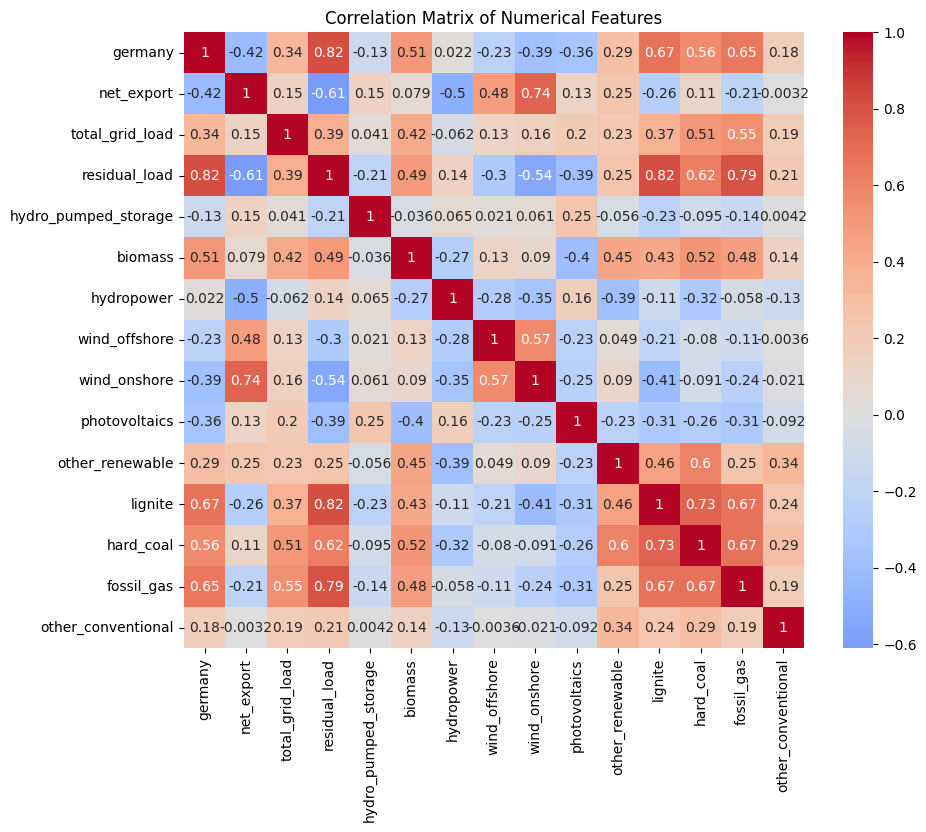

In [41]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numerical Features')
plt.show()